# Facility Security Risk Analytics — EDA & Risk Scoring

All facility data here is **synthetic**, generated by `app.risk.generate` from
the archetype-level distributions in `app.risk.config`. Nothing in this
notebook is measured from a real facility, client, or incident. See
`data/README.md`.

This notebook is an interactive entry point to `backend/app/risk`. The
canonical dataset regenerates with:

```bash
cd backend && uv run python -m app.risk
```

Run this notebook against the backend environment:

```bash
cd backend && uv run jupyter lab
```

## Scoring convention

Seven factors, scored 1-5, weighted:

| Factor | Weight | Polarity |
|---|---|---|
| Asset criticality / value | 20% | higher = more risk |
| Public accessibility | 15% | higher = more risk |
| Perimeter vulnerability | 15% | higher = more risk |
| Threat exposure | 15% | higher = more risk |
| Existing countermeasures | 20% | **inverse** — higher = *stronger* countermeasures = less risk |
| Site complexity | 10% | higher = more risk |
| Response readiness | 5% | higher = *slower/worse* response = more risk |

`existing_countermeasures` is the one factor the project brief calls out as
inverse; it's inverted (`6 - score`) before weighting so every factor's
contribution lands in the same risk-increasing polarity. `response_readiness`
is scored directly in that same polarity (5 = poor readiness) for
consistency — this is a modeling choice made in `app/risk/config.py`, not
part of the original brief, and is documented there too.

The weighted average (naturally 1-5) is rescaled to a **0-100** `risk_score`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "backend"))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from app.risk.config import ARCHETYPES, FACTORS, WEIGHTS, INVERSE_FACTORS
from app.risk.scoring import factor_contributions

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

FLAGS = ["cameras", "access_control", "guards", "lighting", "fencing"]
ARCHETYPE_ORDER = list(ARCHETYPES.keys())
ARCHETYPE_LABELS = {k: v.label for k, v in ARCHETYPES.items()}

## 1. Load & overview

In [2]:
df = pd.read_csv(Path.cwd().parent / "data" / "processed" / "facilities.csv")
df["archetype"] = pd.Categorical(df["archetype"], categories=ARCHETYPE_ORDER, ordered=True)
print(df.shape)
df.head()

(300, 17)


,facility_id,archetype,archetype_label,asset_criticality,public_accessibility,perimeter_vulnerability,threat_exposure,existing_countermeasures,site_complexity,response_readiness,risk_score,cameras,access_control,guards,lighting,fencing,incident_likelihood
0,F001,cultural_heritage_site,Cultural / Heritage Site,4.35,4.08,4.25,3.66,1.23,2.72,2.88,75.96,False,False,False,False,False,64.64
1,F002,cultural_heritage_site,Cultural / Heritage Site,4.76,4.69,3.28,3.26,1.93,4.03,2.77,74.80,False,False,False,False,False,55.89
2,F003,cultural_heritage_site,Cultural / Heritage Site,4.47,4.65,4.05,3.30,4.10,3.26,2.49,63.11,True,True,True,True,True,36.12
3,F004,cultural_heritage_site,Cultural / Heritage Site,4.53,4.80,4.13,2.53,2.76,3.57,2.93,69.41,False,True,True,True,False,51.76
4,F005,cultural_heritage_site,Cultural / Heritage Site,3.47,4.37,3.52,2.55,2.41,4.40,2.28,63.30,False,False,False,False,False,48.87


In [3]:
df.groupby("archetype_label", observed=True).size().rename("n_facilities").to_frame()

,n_facilities
archetype_label,
Commercial Retail Complex,75
Critical Infrastructure (Substation / Warehouse),75
Cultural / Heritage Site,75
Mixed-Use Tower,75


## 2. Risk score distribution by archetype

Sanity check against the brief: critical infrastructure should skew high on
`asset_criticality` but low on `public_accessibility`; cultural/heritage and
retail should show the highest public-accessibility risk.

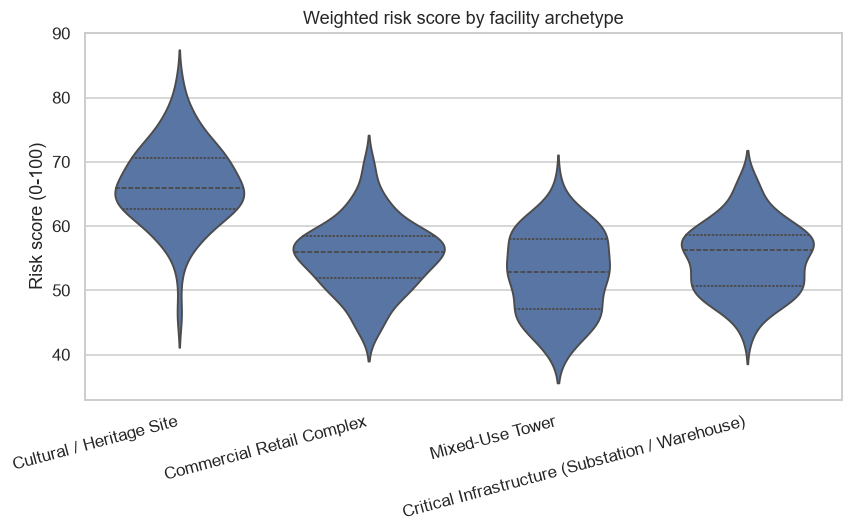

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
order = [ARCHETYPE_LABELS[k] for k in ARCHETYPE_ORDER]
sns.violinplot(data=df, x="archetype_label", y="risk_score", order=order, ax=ax, inner="quartile")
ax.set_xlabel("")
ax.set_ylabel("Risk score (0-100)")
ax.set_title("Weighted risk score by facility archetype")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.tight_layout()

## 3. Factor score distributions by archetype

Small multiples, one panel per factor, boxplots across archetypes. Confirms
the generator matches the qualitative profile each archetype was designed for.

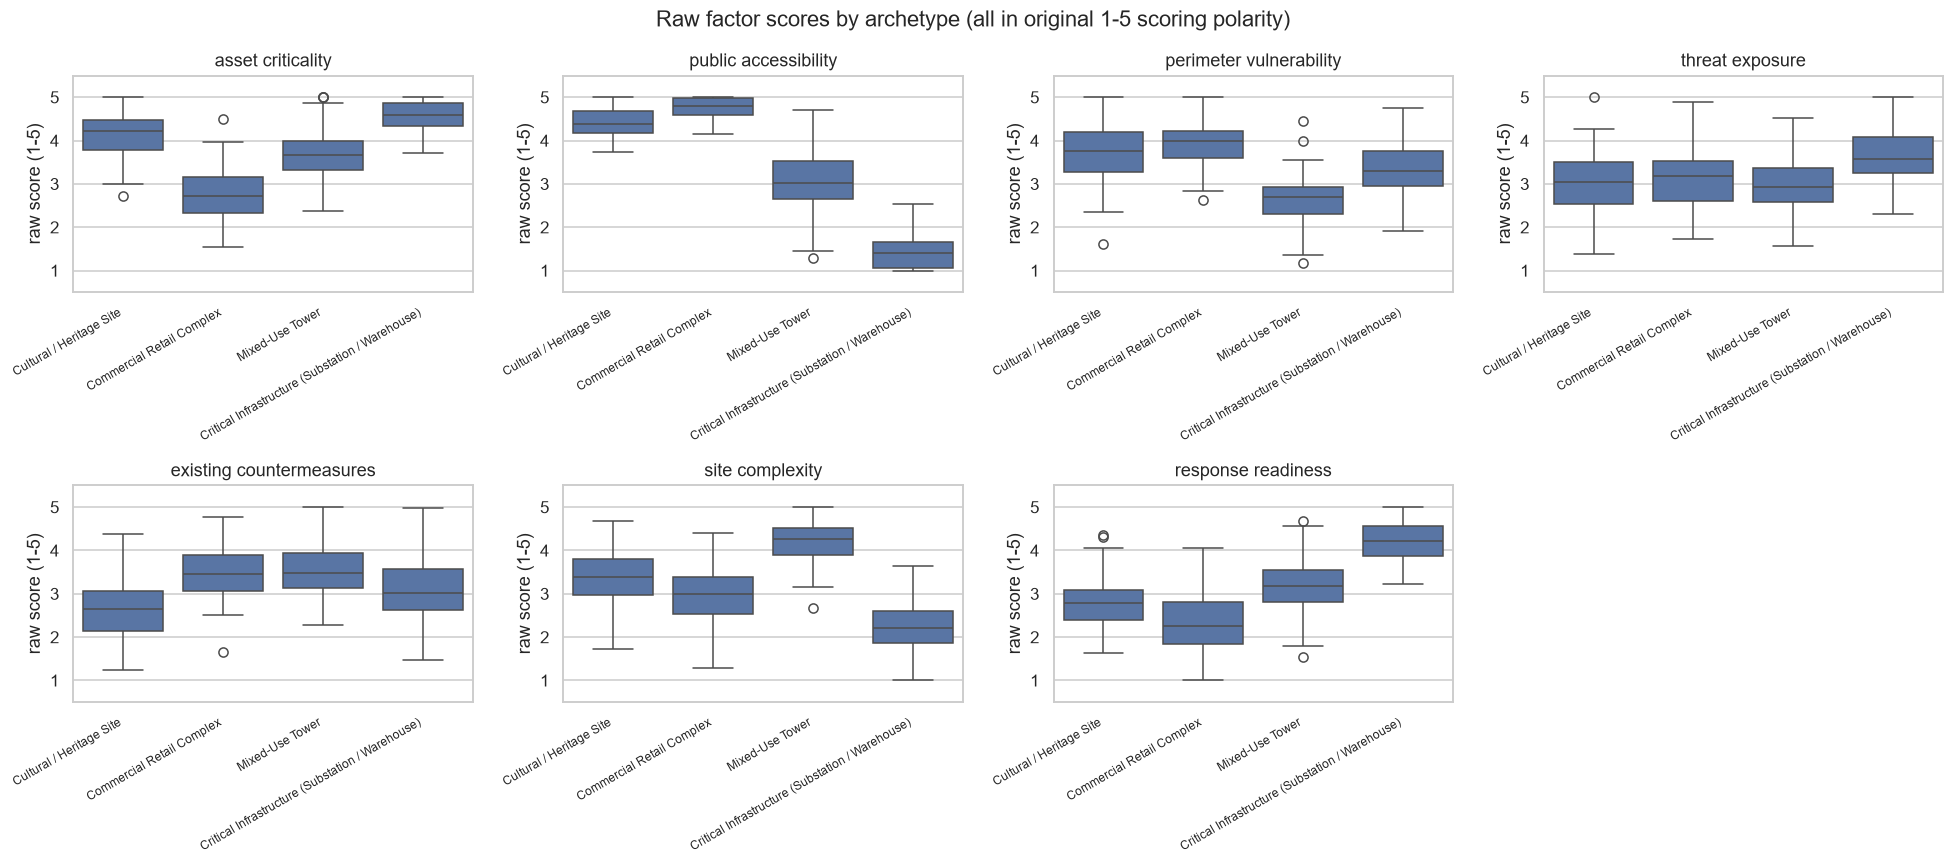

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, factor in zip(axes.flat, FACTORS):
    sns.boxplot(data=df, x="archetype_label", y=factor, order=order, ax=ax)
    ax.set_title(factor.replace("_", " "))
    ax.set_xlabel("")
    ax.set_ylabel("raw score (1-5)")
    ax.set_ylim(0.5, 5.5)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
axes.flat[-1].axis("off")
fig.suptitle("Raw factor scores by archetype (all in original 1-5 scoring polarity)")
fig.tight_layout()

## 4. Risk score breakdown — weighted contributions

Mean weighted contribution of each factor per archetype (already inverted for
`existing_countermeasures`, so every bar segment is in risk-increasing
polarity and the stack sums to the weighted-average risk score, 1-5).

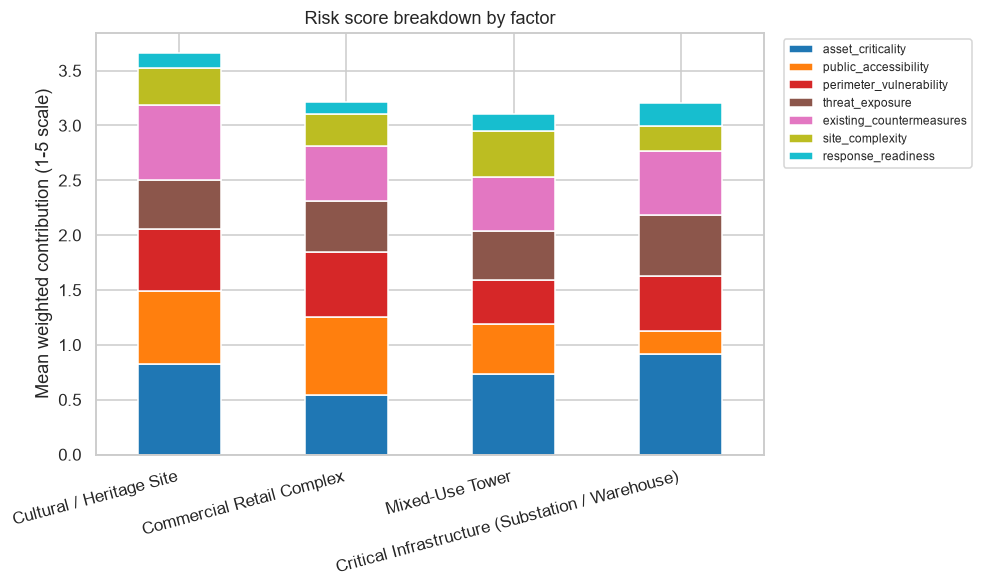

In [6]:
contrib_rows = [factor_contributions(row[list(FACTORS)].to_dict()) for _, row in df.iterrows()]
contrib_df = pd.DataFrame(contrib_rows)
contrib_df["archetype_label"] = df["archetype_label"].values
mean_contrib = contrib_df.groupby("archetype_label", observed=True)[list(FACTORS)].mean().loc[order]

fig, ax = plt.subplots(figsize=(9, 5.5))
mean_contrib.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_ylabel("Mean weighted contribution (1-5 scale)")
ax.set_xlabel("")
ax.set_title("Risk score breakdown by factor")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.tight_layout()

## 5. Sensitivity analysis — which factors drive risk most

`risk_score` is a deterministic weighted sum, so a factor's correlation with
it mixes its **assigned weight** with how much that factor actually *varies*
in the data (a high-weight factor with near-zero variance won't correlate
with anything). We look at both: the fixed weight, and the empirical
contribution to variance (weight × std, i.e. each factor's realized
sensitivity in this dataset).

In [7]:
risk_polarity = df[list(FACTORS)].copy()
risk_polarity["existing_countermeasures"] = 6 - risk_polarity["existing_countermeasures"]

sensitivity = pd.DataFrame({
    "weight": pd.Series(WEIGHTS),
    "std_dev": risk_polarity.std(),
    "corr_with_risk_score": risk_polarity.corrwith(df["risk_score"]),
})
sensitivity["weight_x_std"] = sensitivity["weight"] * sensitivity["std_dev"]
sensitivity = sensitivity.sort_values("weight_x_std", ascending=False)
sensitivity.round(3)

,weight,std_dev,corr_with_risk_score,weight_x_std
public_accessibility,0.15,1.388,0.362,0.208
asset_criticality,0.20,0.854,0.335,0.171
existing_countermeasures,0.20,0.762,0.667,0.152
perimeter_vulnerability,0.15,0.768,0.478,0.115
threat_exposure,0.15,0.720,0.186,0.108
site_complexity,0.10,0.916,0.099,0.092
response_readiness,0.05,0.910,-0.070,0.046


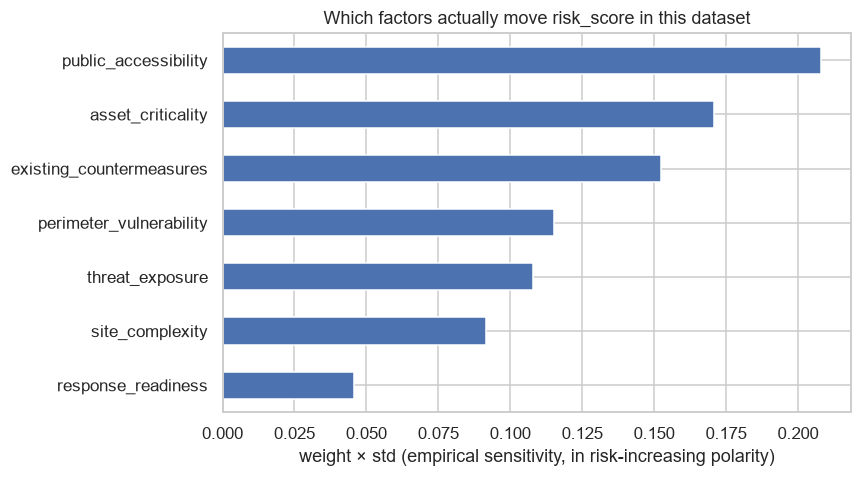

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sensitivity["weight_x_std"].sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("deep")[0])
ax.set_xlabel("weight × std (empirical sensitivity, in risk-increasing polarity)")
ax.set_title("Which factors actually move risk_score in this dataset")
fig.tight_layout()

## 6. Radar charts per archetype

Mean raw factor profile per archetype, shown in the **original** 1-5 scoring
polarity (i.e. `existing_countermeasures` is shown as-scored — high means
*strong* countermeasures — since that reads more naturally on a profile chart
than its risk-inverted form).

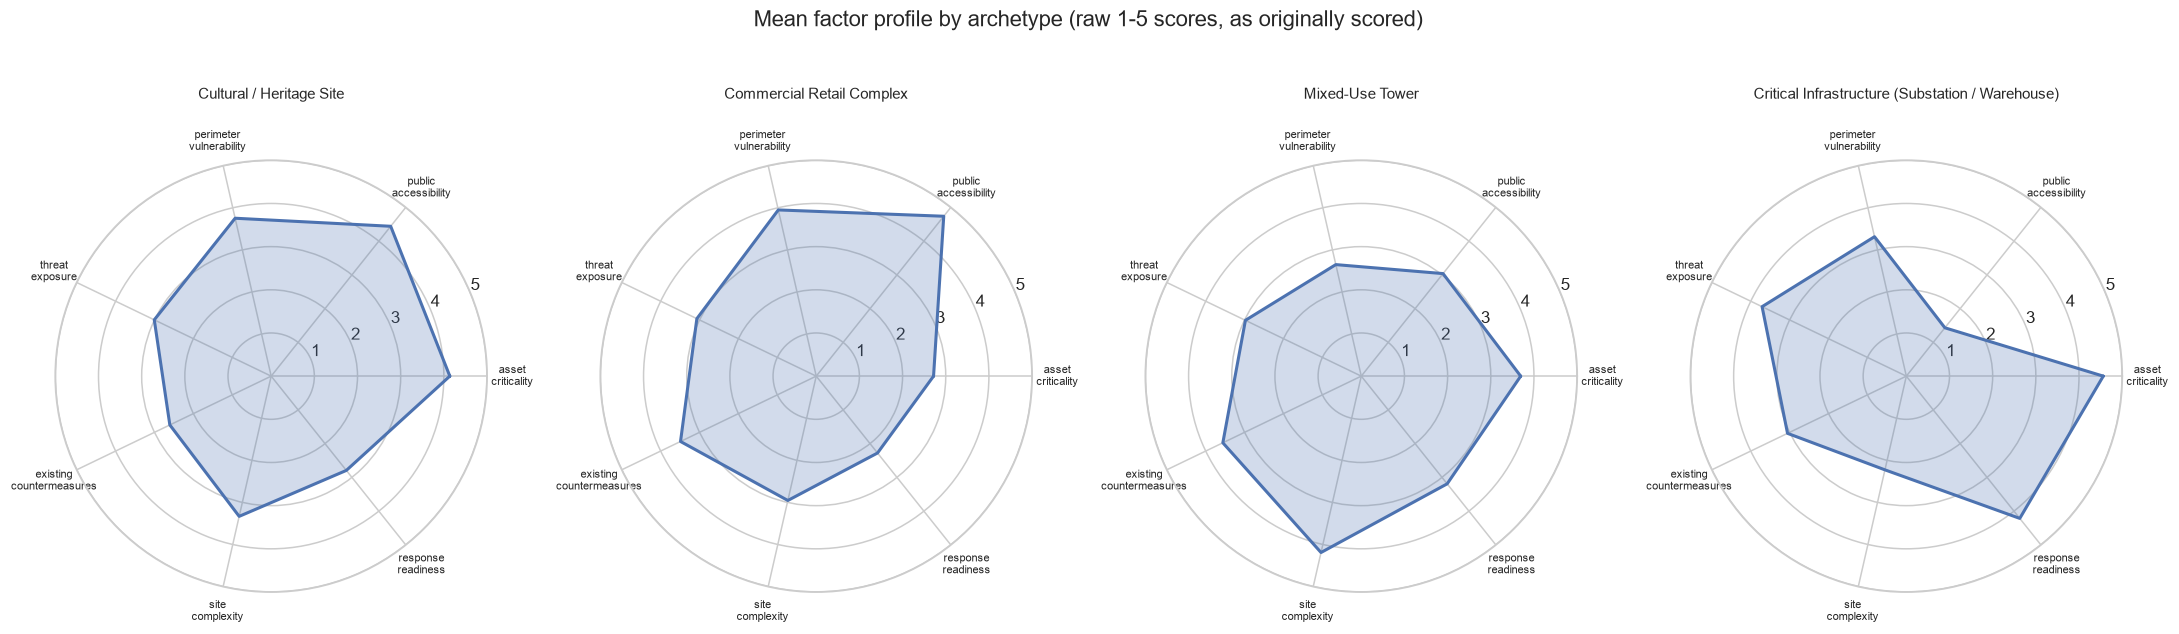

In [9]:
angles = np.linspace(0, 2 * np.pi, len(FACTORS), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5), subplot_kw=dict(polar=True))
for ax, key in zip(axes, ARCHETYPE_ORDER):
    means = df.loc[df["archetype"] == key, list(FACTORS)].mean()
    values = means.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.replace("_", "\n") for f in FACTORS], fontsize=7)
    ax.set_ylim(0, 5)
    ax.set_title(ARCHETYPE_LABELS[key], fontsize=10, pad=20)
fig.suptitle("Mean factor profile by archetype (raw 1-5 scores, as originally scored)", y=1.05)
fig.tight_layout()

## 7. Countermeasure flags vs. `existing_countermeasures` score

The five boolean flags were generated *from* the countermeasures score
(`app/risk/generate.py`), so this is a check that the correlation the brief
asked for actually shows up in the data, not new information.

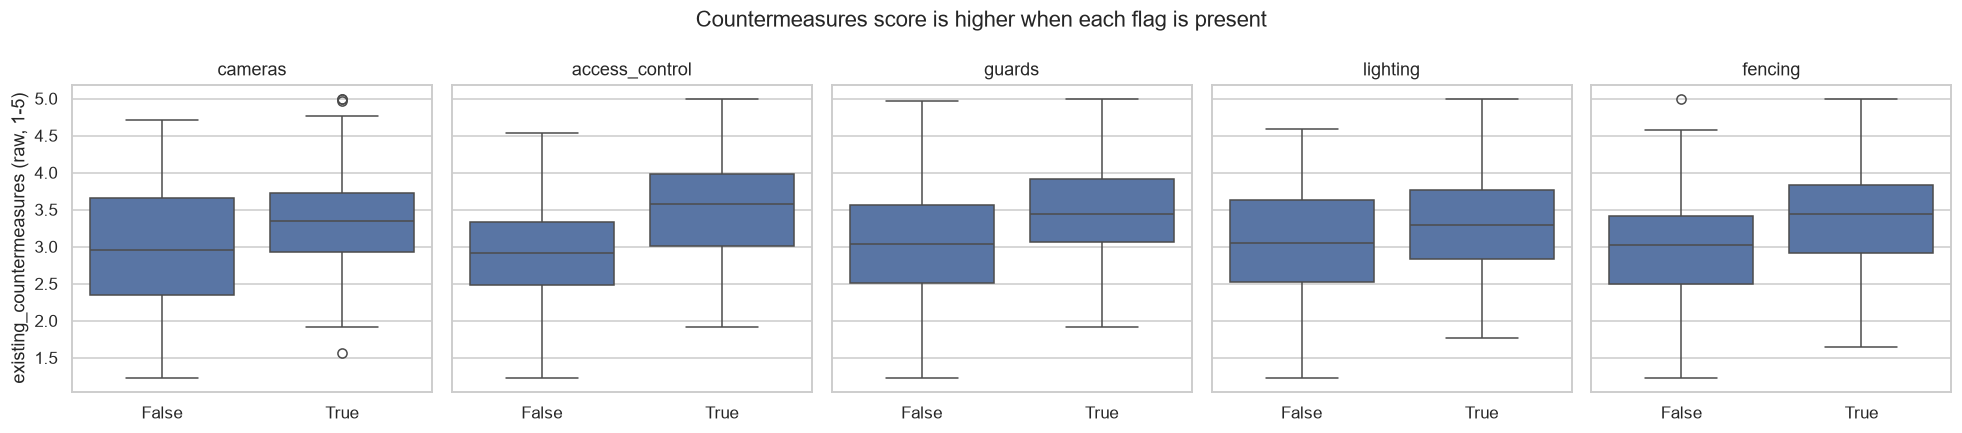

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, flag in zip(axes, FLAGS):
    sns.boxplot(data=df, x=flag, y="existing_countermeasures", ax=ax)
    ax.set_title(flag)
    ax.set_xlabel("")
axes[0].set_ylabel("existing_countermeasures (raw, 1-5)")
fig.suptitle("Countermeasures score is higher when each flag is present")
fig.tight_layout()

In [11]:
df[FLAGS].corrwith(df["existing_countermeasures"]).sort_values(ascending=False).rename(
    "corr_with_countermeasures_score"
).to_frame().round(2)

,corr_with_countermeasures_score
access_control,0.42
guards,0.29
fencing,0.29
cameras,0.27
lighting,0.20


## 8. Synthetic outcome variable — `incident_likelihood`

> **`incident_likelihood` is a fully synthetic, simulated outcome — it is not
> derived from any real incident data.** It exists to give the ML step below
> something to predict. It's built in `app/risk/generate.py` as:
>
> `incident_likelihood = 0.72 × risk_score + 28 × interaction − 8 + noise`,
> clipped to [0, 100]
>
> where `interaction = threat_exposure × (1 − countermeasure_strength)`
> (both rescaled 0-1) — a deliberate nonlinear term the linear `risk_score`
> formula can't express — plus `noise ~ N(0, 6)` standing in for the many
> real-world drivers a 7-factor model can't capture. It's a proxy target
> chosen to make the interpretable-ML section below demonstrate something
> real (recovering a known interaction effect), not a claim about actual
> incident rates.

corr(risk_score, incident_likelihood) = 0.769


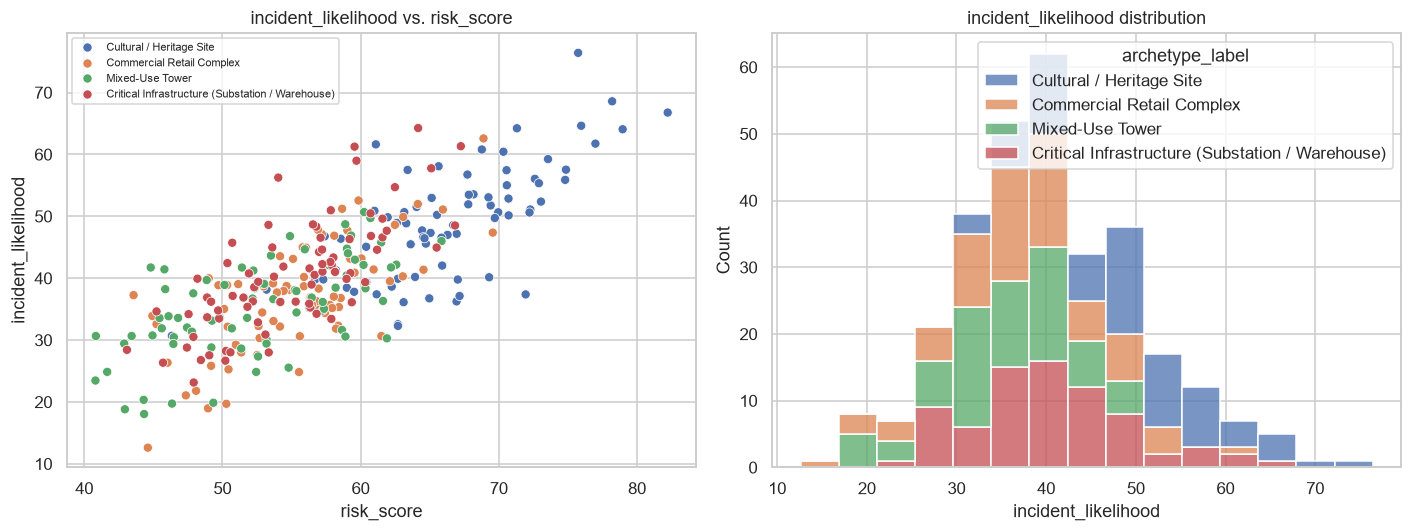

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="risk_score", y="incident_likelihood", hue="archetype_label", ax=axes[0])
axes[0].set_title("incident_likelihood vs. risk_score")
axes[0].legend(fontsize=7, loc="upper left")

sns.histplot(data=df, x="incident_likelihood", hue="archetype_label", multiple="stack", bins=15, ax=axes[1])
axes[1].set_title("incident_likelihood distribution")
fig.tight_layout()
print("corr(risk_score, incident_likelihood) =", round(df["risk_score"].corr(df["incident_likelihood"]), 3))

## 9. Interpretable ML — predicting `incident_likelihood`

Two small, interpretable models on the 7 risk factors + 5 countermeasure
flags (12 features): **Ridge regression** (linear, coefficients read directly
as "+X points of incident_likelihood per unit of factor") and a **shallow
gradient-boosted trees** model (few, shallow trees — enough to pick up the
threat × countermeasures interaction Ridge can't, while staying small enough
for SHAP to explain cleanly). The goal is a clear explainability story, not
maximizing accuracy.

In [13]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = list(FACTORS) + FLAGS
X = df[FEATURE_COLS].copy()
X[FLAGS] = X[FLAGS].astype(float)
y = df["incident_likelihood"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLS, index=X_test.index)

ridge = Ridge(alpha=1.0, random_state=42).fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
print(f"Ridge   R2={r2_score(y_test, ridge_pred):.3f}  MAE={mean_absolute_error(y_test, ridge_pred):.2f}")

gbm = GradientBoostingRegressor(n_estimators=50, max_depth=2, learning_rate=0.1, random_state=42)
gbm.fit(X_train, y_train)
gbm_pred = gbm.predict(X_test)
print(f"GBM     R2={r2_score(y_test, gbm_pred):.3f}  MAE={mean_absolute_error(y_test, gbm_pred):.2f}")

Ridge   R2=0.559  MAE=5.12
GBM     R2=0.461  MAE=5.70


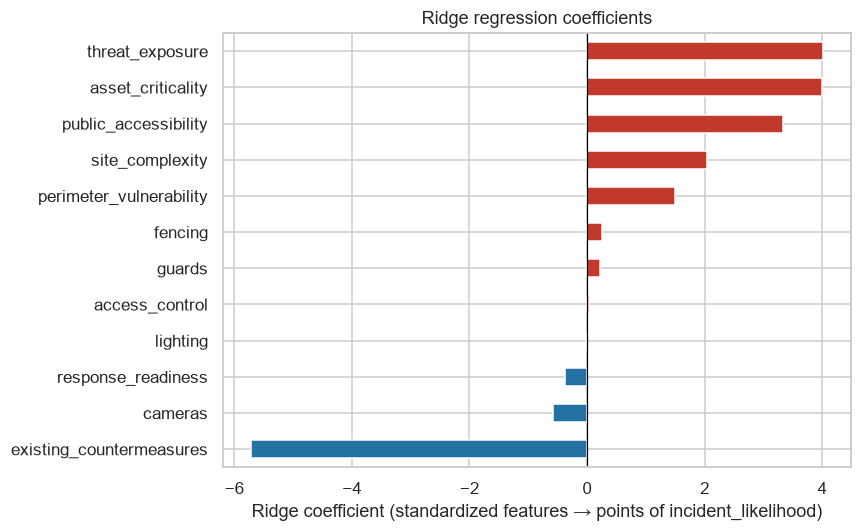

In [14]:
ridge_coefs = pd.Series(ridge.coef_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#c0392b" if v > 0 else "#2471a3" for v in ridge_coefs.values]
ridge_coefs.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Ridge coefficient (standardized features → points of incident_likelihood)")
ax.set_title("Ridge regression coefficients")
ax.axvline(0, color="black", linewidth=0.8)
fig.tight_layout()

## 10. SHAP — top risk-driving and risk-reducing factors

SHAP values on the shallow GBM show each feature's contribution to a given
prediction, including the nonlinear threat × countermeasures interaction the
Ridge model structurally can't represent.

**Stability check (n=52 vs n=300):** this ranking was re-checked after
scaling the dataset from 13 to 75 facilities per archetype (52 → 300 rows
total, same generation logic, weights, and interaction term unchanged). The
ranking is **not** stable at n=52:

- `existing_countermeasures` holds the #1 spot at both sample sizes.
- `threat_exposure` moves from **#4** (mean \|SHAP\|=1.51) at n=52 up to
  **#2** (mean \|SHAP\|=2.72) at n=300 — consistent with it being the
  deliberate interaction partner with `existing_countermeasures`; the effect
  needed more data to separate from noise.
- `perimeter_vulnerability` (#2 at n=52, 2.83) and `response_readiness` (#3
  at n=52, 1.95) both fall toward the bottom of the ranking at n=300 (0.85
  and ~0.00 respectively) — their earlier rank was a small-sample artifact,
  not a real effect the model recovered.

**Takeaway:** at n=52, only the #1 rank (`existing_countermeasures`) was
trustworthy; the rest of the ordering reshuffled substantially once given
more data. Since more synthetic data is free to generate here, n=300 is used
as this project's dataset from this point on for exactly this reason.

C:\Users\30697\Projects\facility-security-risk-analytics\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


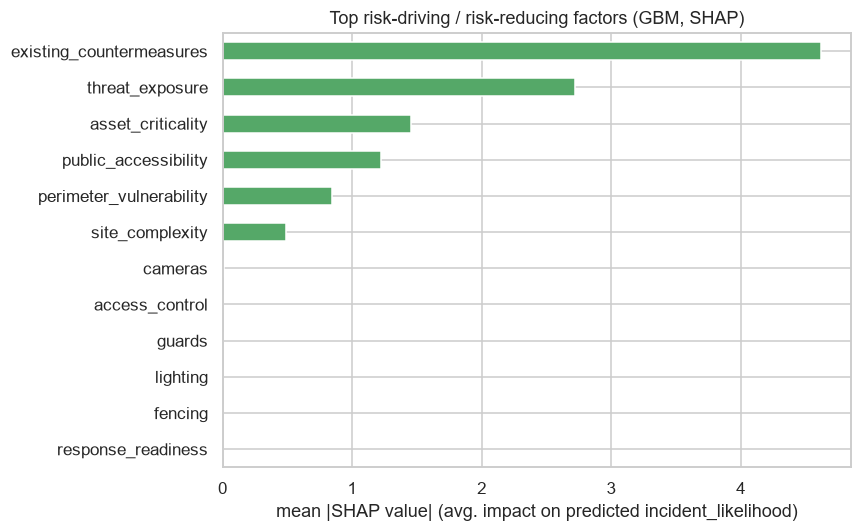

In [15]:
import shap

explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(X)

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
mean_abs_shap.plot(kind="barh", ax=ax, color=sns.color_palette("deep")[2])
ax.set_xlabel("mean |SHAP value| (avg. impact on predicted incident_likelihood)")
ax.set_title("Top risk-driving / risk-reducing factors (GBM, SHAP)")
fig.tight_layout()

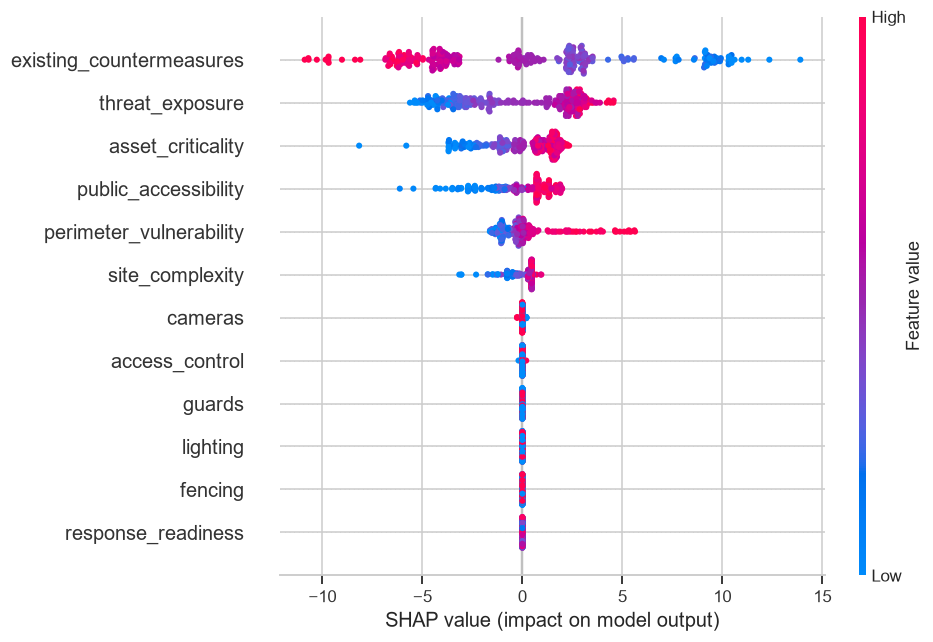

In [16]:
shap.summary_plot(shap_values, X, feature_names=FEATURE_COLS, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.tight_layout()

## 11. Save artifacts

The trained GBM (plus scaler and feature order, needed for the Ridge model)
are saved to `models/` so the future FastAPI what-if endpoint can load them
instead of retraining. The mean \|SHAP\| feature ranking is saved alongside
it as `shap_summary.json`, so the API's `/api/shap-summary` route can serve
it directly rather than recomputing SHAP on every request. `models/` is
gitignored — see `models/README.md`.

In [17]:
import joblib

models_dir = Path.cwd().parent / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(
    {
        "gbm": gbm,
        "ridge": ridge,
        "scaler": scaler,
        "feature_cols": FEATURE_COLS,
        "flag_cols": FLAGS,
        "factor_cols": list(FACTORS),
    },
    models_dir / "incident_likelihood_model.joblib",
)
print("Saved", models_dir / "incident_likelihood_model.joblib")

shap_summary = {
    "model": "gbm",
    "n_samples": len(df),
    "features": [
        {"feature": feature, "mean_abs_shap": round(float(value), 3)}
        for feature, value in mean_abs_shap.sort_values(ascending=False).items()
    ],
}
shap_summary_path = models_dir / "shap_summary.json"
shap_summary_path.write_text(json.dumps(shap_summary, indent=2))
print("Saved", shap_summary_path)

Saved C:\Users\30697\Projects\facility-security-risk-analytics\models\incident_likelihood_model.joblib
Saved C:\Users\30697\Projects\facility-security-risk-analytics\models\shap_summary.json


## Summary

- Synthetic dataset (300 facilities, 4 archetypes, 75 per archetype) matches
  the qualitative profile each archetype was designed for (Sections 2-3).
- The empirical sensitivity ranking for `risk_score` (Section 5) is close
  across the top three factors — `public_accessibility`, `asset_criticality`,
  and `existing_countermeasures` — reflecting both their weights and how much
  each factor actually varies across archetypes in this sample; no single
  factor dominates.
- Countermeasure flags correlate with the countermeasures score as designed
  (Section 7).
- Ridge slightly outperforms the shallow GBM on the synthetic
  `incident_likelihood` target at this sample size (R²=0.56 vs 0.46) — fine,
  since the priority here is interpretability, not beating a linear
  baseline. Via SHAP, the GBM still recovers the built-in threat ×
  countermeasures interaction: scaling from n=52 to n=300 moved
  `threat_exposure` from #4 to #2 in the SHAP ranking, which is exactly what
  recovering a real, designed-in interaction effect should look like as
  sample size grows (Section 10).

**Next**: graduate `app/risk/scoring.py` + the saved model into a FastAPI
service with a `/what-if` endpoint (recompute risk_score and predicted
incident_likelihood when countermeasure flags are toggled), then a React
dashboard (archetype selector, radar chart, risk breakdown, what-if
toggles, SHAP-based "top risk-reducing factors" panel).